# Лабораторная работа №4. Часть 1
## Оптимизация раскладки клавиатуры с помощью генетического алгоритма

**Выполнил:** Студент группы 71 (1)  
**Вариант:** 13

**Цель работы:** Найти оптимальное расположение клавиш на клавиатуре для минимизации перемещения пальцев при наборе заданных слов.

**Слова для оптимизации (Вариант 13):**
1. "разглагольствовать" (сложное)
2. "видеоконференция" (нормальное)
3. "бакалавриат" (лёгкое)

## Теоретическая справка

**Генетический алгоритм (ГА)** — это эвристический алгоритм поиска, используемый для решения задач оптимизации и моделирования путём случайного подбора, комбинирования и вариации искомых параметров с использованием механизмов, аналогичных естественному отбору в природе.

### Основные понятия:
1. **Ген** — атомарная единица генотипа (в нашем случае: пара "символ - координата").
2. **Хромосома (Индивид)** — совокупность генов, представляющая одно решение задачи (конкретная раскладка клавиатуры).
3. **Популяция** — набор индивидов (множество разных раскладок).
4. **Функция приспособленности (Fitness Function)** — функция, оценивающая качество индивида. Чем меньше суммарное расстояние, которое проходят пальцы, тем лучше особь.
5. **Скрещивание (Crossover)** — оператор, создающий новых индивидов (потомков) путем комбинирования частей родительских хромосом.
6. **Мутация** — случайное изменение генов у потомка для поддержания генетического разнообразия и предотвращения преждевременной сходимости.
7. **Элитизм** — перенос лучших особей из текущего поколения в следующее без изменений.

## 1. Установка и импорт библиотек

In [78]:
!pip install numpy pandas matplotlib pillow requests


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [79]:
import json
import os
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

%matplotlib inline

# Фиксируем seed для воспроизводимости результатов
random.seed(13)
np.random.seed(13)

## 2. Подготовка данных

Согласно варианту 13, мы используем три слова. Наша задача — составить частотный словарь переходов (биграмм) между буквами. Мы будем оптимизировать раскладку так, чтобы часто встречающиеся пары букв находились близко друг к другу.

**Обработка текста:**
- Приведение к нижнему регистру.
- Замена 'ё' на 'е'.
- Удаление лишних символов.
- Замена дефисов на пробелы (по условию).

In [80]:
# Слова согласно варианту 13
target_words = [
    "разглагольствовать",
    "видеоконференция",
    "бакалавриат"
]

# Создаем массив данных, повторяя слова много раз для веса
messages = [np.repeat(target_words, 1000)]

# Создаем DataFrame
df = pd.DataFrame(dict(msg=np.concatenate(messages)))
df.msg = df.msg.str.lower()

# Предобработка согласно заданию
df.msg = df.msg.str.replace('ё', 'е')
df.msg = df.msg.str.replace(u'\xa0', u' ')
df.msg = df.msg.str.replace(u'\-', u' ') # Замена дефиса на пробел
df.msg = df.msg.str.replace('[^a-zа-я0-9\s?,.!]', '', regex=True)

# Собираем единую строку для анализа
sequence = list(''.join(df[~df.msg.isna()].msg.values))
charmap = np.unique(sequence)

# Создаем биграммы (пары символов) и считаем их частоту
bisequence = (pd.Series(sequence[:-1]) + pd.Series(sequence[1:]))
BISEQUENCE_FREQS = bisequence.value_counts().reset_index()
BISEQUENCE_FREQS.columns = ['biseq', 'freq']

print(f"Используемые символы ({len(charmap)} шт.): {charmap}")
print("\nТоп-10 самых частых переходов (биграмм):")
display(BISEQUENCE_FREQS.head(10))

Используемые символы (19 шт.): ['а' 'б' 'в' 'г' 'д' 'е' 'з' 'и' 'к' 'л' 'н' 'о' 'р' 'с' 'т' 'ф' 'ц' 'ь'
 'я']

Топ-10 самых частых переходов (биграмм):


,biseq,freq
0,ла,2000
1,ат,2000
2,ра,1000
3,ци,1000
4,он,1000
5,нф,1000
6,фе,1000
7,ер,1000
8,ре,1000
9,ен,1000


## 3. Конфигурация клавиатуры

Определяем координаты клавиш на изображении макета. Раскладка разбита на 5 рядов. Это физическое представление "слотов", в которые мы будем помещать буквы.

In [81]:
# Шаблон стандартной раскладки (для набора всех возможных символов)
FIRST_ROW = [list('1234567890')]
SECOND_ROW = [list('йцукенгшщзх')]
THIRD_ROW = [list('фывапролджэ')]
FOURTH_ROW = [list('ячсмитьбю')]
FIFTH_ROW = [list(', .\n')]
ROWS = [FIRST_ROW, SECOND_ROW, THIRD_ROW, FOURTH_ROW, FIFTH_ROW]

# Координаты клавиш (в пикселях) для отрисовки и расчета расстояний
KEYBINDS = [
    # 1 ряд
    [(68,68), (174, 68), (280, 68), (385, 68), (485, 68), 
     (585, 68), (685, 68), (790, 68), (905, 68), (1010, 68)],
    # 2 ряд
    [(60, 201),(155, 201),(255, 201),(345, 201),(445, 201),
     (540, 201),(635, 201),(730, 201),(820, 201),(920, 201),(1015, 201)],
    # 3 ряд
    [(60, 350),(155, 350),(255, 350),(345, 350),(445, 350),
     (540, 350),(635, 350),(730, 350),(820, 350),(920, 350),(1015, 350)],
    # 4 ряд
    [(155, 500),(255, 500),(345, 500),(445, 500),
     (540, 500),(635, 500),(730, 500),(820, 500),(920, 500)],
    # 5 ряд (пробел и т.д.)
    [(224, 645),(530, 645),(855, 645),(980, 645)],
]

print("Конфигурация клавиатуры загружена.")

Конфигурация клавиатуры загружена.


## 4. Генерация особи

Функция `generate_one` создает случайную раскладку. Она берет все доступные символы и случайным образом назначает им координаты клавиш.

In [82]:
def generate_one():
    """Генерирует одну случайную раскладку (хромосому)"""
    mapper = {}
    
    # 1. Собираем все доступные координаты (слоты) из KEYBINDS
    available_slots = []
    for row in KEYBINDS:
        for coord in row:
            # Используем уменьшенные координаты для удобства расчетов
            available_slots.append((coord[0]//10, coord[1]//10))
            
    # 2. Собираем все символы, которые могут быть на клавиатуре
    all_chars = []
    for row in ROWS:
        for group in row:
            all_chars.extend(group)
            
    # 3. Перемешиваем символы для создания случайной особи
    random.shuffle(all_chars)
    
    # 4. Назначаем символы на слоты
    for i, char in enumerate(all_chars):
        if i < len(available_slots):
            mapper[char] = available_slots[i]
            
    return mapper

# Тест генерации
test_ind = generate_one()
print(f"Пример сгенерированной особи (первые 5 генов): {list(test_ind.items())[:5]}")

Пример сгенерированной особи (первые 5 генов): [('л', (6, 6)), ('э', (17, 6)), ('4', (28, 6)), ('я', (38, 6)), ('ы', (48, 6))]


## 5. Визуализация раскладки

Эта функция отрисовывает текущую раскладку. 
**Важно:** Реализована защита от проблем со шрифтами на macOS и Linux. Если локальный шрифт не найден, скрипт скачивает `Roboto-Bold.ttf`, поддерживающий кириллицу.

Тестовая отрисовка случайной раскладки:


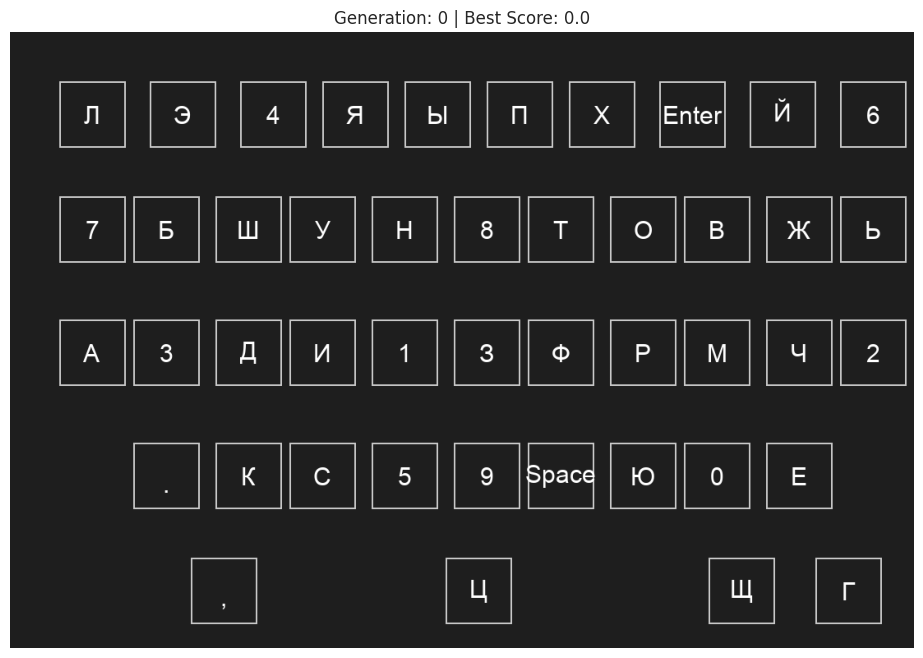

In [83]:
def get_font(size=30):
    """Загружает шрифт с поддержкой кириллицы, чтобы избежать 'квадратиков'"""
    # Список путей к шрифтам для разных ОС
    font_paths = [
        "Roboto-Bold.ttf", # Локальный, если уже скачан
        "/System/Library/Fonts/Supplemental/Arial.ttf", # macOS
        "/System/Library/Fonts/Helvetica.ttc", # macOS
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", # Linux
        "C:\\Windows\\Fonts\\arial.ttf" # Windows
    ]
    
    # Пытаемся найти системный шрифт
    for path in font_paths:
        if os.path.exists(path):
            try:
                return ImageFont.truetype(path, size)
            except:
                continue
                
    # Если ничего не нашли, скачиваем Roboto из Google Fonts
    if not os.path.exists("Roboto-Bold.ttf"):
        print("Скачивание шрифта Roboto-Bold.ttf...")
        try:
            url = "https://github.com/google/fonts/raw/main/apache/roboto/Roboto-Bold.ttf"
            r = requests.get(url, allow_redirects=True)
            with open("Roboto-Bold.ttf", 'wb') as f:
                f.write(r.content)
            return ImageFont.truetype("Roboto-Bold.ttf", size)
        except Exception as e:
            print(f"Не удалось скачать шрифт: {e}. Используем дефолтный.")
            
    return ImageFont.load_default()

def plot_keyboard(mapper, generation_num=0, score=0):
    """Отрисовка клавиатуры"""
    # Создаем холст
    W, H = 1100, 750
    image = Image.new('RGB', (W, H), color=(30, 30, 30))
    draw = ImageDraw.Draw(image)
    font = get_font(30)

    # Рисуем каждую клавишу
    for char, coords in mapper.items():
        # Красивое отображение спецсимволов
        label = char.upper()
        if char == '\n': label = 'Enter'
        if char == ' ': label = 'Space'
        
        # Координаты (масштабируем обратно)
        x, y = coords[0] * 10, coords[1] * 10
        
        # Рисуем кнопку
        box_size = 80
        draw.rectangle([x, y, x + box_size, y + box_size], outline=(200, 200, 200), width=2)
        
        # Рисуем текст по центру кнопки
        # Используем textbbox для центрирования (pillow >= 9.2)
        if hasattr(draw, 'textbbox'):
            bbox = draw.textbbox((0, 0), label, font=font)
            w = bbox[2] - bbox[0]
            h = bbox[3] - bbox[1]
        else:
            # Старый метод для совместимости
            w, h = draw.textsize(label, font=font)
            
        draw.text((x + (box_size - w)/2, y + (box_size - h)/2 - 5), label, font=font, fill=(255, 255, 255))

    # Вывод с помощью matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.title(f"Generation: {generation_num} | Best Score: {score:.1f}")
    plt.axis('off')
    plt.show()

# Проверка отрисовки
print("Тестовая отрисовка случайной раскладки:")
plot_keyboard(test_ind, generation_num=0)

## 6. Функция приспособленности (Fitness)

Рассчитывает суммарное расстояние, которое проходят пальцы при наборе текста.
$$ Score = \sum (Freq_{char1, char2} \times Distance_{char1, char2}) $$
Задача — **минимизировать** это значение.

In [84]:
def get_scores(population):
    scores = []
    for ind_mapper in population:
        current_score = 0
        
        # Кэшируем координаты текущей особи в numpy array для скорости
        key_coords = {k: np.array(v) for k, v in ind_mapper.items()}
        
        # Проходим по всем биграммам в нашем тексте
        for _, row in BISEQUENCE_FREQS.iterrows():
            char1, char2 = row['biseq'][0], row['biseq'][1]
            freq = row['freq']
            
            # Если оба символа есть на клавиатуре (они должны быть)
            if char1 in key_coords and char2 in key_coords:
                # Считаем Евклидово расстояние между клавишами
                dist = np.linalg.norm(key_coords[char1] - key_coords[char2])
                current_score += dist * freq
            else:
                # Штраф, если символа нет (теоретически невозможно при generate_one)
                current_score += 1000 * freq
                
        scores.append(current_score)
    return scores

## 7. Генетические операторы: Мутация и Скрещивание

1. **Мутация (Swap):** Меняет местами две случайные клавиши. Это позволяет алгоритму "выпрыгивать" из локальных минимумов.
2. **Скрещивание (Crossover):** Используется метод, сохраняющий уникальность генов (например, Order Crossover). Берем часть раскладки от одного родителя, а недостающие символы заполняем из второго, сохраняя их относительный порядок или позиции.

In [85]:
def mutation(individual, mutation_rate=0.1):
    """Меняет местами две случайные клавиши с вероятностью mutation_rate"""
    new_ind = individual.copy()
    keys = list(new_ind.keys())
    
    # Шанс мутации
    if random.random() < mutation_rate:
        # Выбираем два случайных ключа
        k1, k2 = random.sample(keys, 2)
        # Меняем координаты местами
        new_ind[k1], new_ind[k2] = new_ind[k2], new_ind[k1]
        
    return new_ind

def crossover(parentA, parentB):
    """
    Скрещивание: берем координаты случайного подмножества символов от Родителя А,
    остальные координаты берем из Родителя Б (обменивая их местами, чтобы сохранить структуру).
    """
    child = parentA.copy()
    keys = list(parentA.keys())
    
    # Простая реализация кроссовера для перестановок:
    # Проходим по всем клавишам
    for k in keys:
        # С вероятностью 50% берем позицию из родителя B
        if random.random() > 0.5:
            pos_in_B = parentB[k]
            
            # Находим, какой символ сейчас занимает эту позицию у ребенка
            # (так как child изначально копия A)
            char_at_pos = [char for char, pos in child.items() if pos == pos_in_B][0]
            
            # Меняем местами координаты текущего символа k и того, кто занимал место
            # Это гарантирует, что все координаты уникальны и заняты
            child[char_at_pos] = child[k]
            child[k] = pos_in_B
            
    return child

## 8. Создание нового поколения (Селекция)

Используем **турнирный отбор** и **элитизм** (сохраняем лучших без изменений).

In [86]:
def create_next_generation(population, scores, pop_size, elite_size=4):
    # Сортируем популяцию по оценке (меньше - лучше)
    sorted_pop_data = sorted(zip(population, scores), key=lambda x: x[1])
    sorted_pop = [x[0] for x in sorted_pop_data]
    
    new_population = []
    
    # 1. Элитизм: сохраняем топ лучших
    new_population.extend(sorted_pop[:elite_size])
    
    # 2. Размножение и мутация
    # Отбираем родителей из топ 50% (турнир)
    parents_pool = sorted_pop[:pop_size // 2]
    
    while len(new_population) < pop_size:
        # Случайный выбор двух родителей
        parent1 = random.choice(parents_pool)
        parent2 = random.choice(parents_pool)
        
        # Скрещивание
        child = crossover(parent1, parent2)
        
        # Мутация (вероятность выше для разнообразия)
        child = mutation(child, mutation_rate=0.3)
        
        new_population.append(child)
        
    return new_population

## 9. Запуск Генетического Алгоритма

Запустим алгоритм на 50 поколений с размером популяции 100 особей. Будем выводить прогресс и в конце покажем лучшую раскладку и график сходимости.

Старт оптимизации...

Поколение 0: Лучшее = 1636043.92, Среднее = 2003691.36
Поколение 5: Лучшее = 1331504.65, Среднее = 1707172.29
Поколение 10: Лучшее = 1123669.42, Среднее = 1580348.80
Поколение 15: Лучшее = 1123669.42, Среднее = 1548221.93
Поколение 20: Лучшее = 1082701.17, Среднее = 1352320.69
Поколение 25: Лучшее = 1032145.29, Среднее = 1197063.59
Поколение 30: Лучшее = 963197.59, Среднее = 1166331.89
Поколение 35: Лучшее = 941785.39, Среднее = 1154090.60
Поколение 40: Лучшее = 915337.82, Среднее = 1143620.14
Поколение 45: Лучшее = 891847.36, Среднее = 1100233.95
Поколение 49: Лучшее = 867219.41, Среднее = 1046641.75

Оптимизация завершена!
Финальный лучший результат: 867219.41


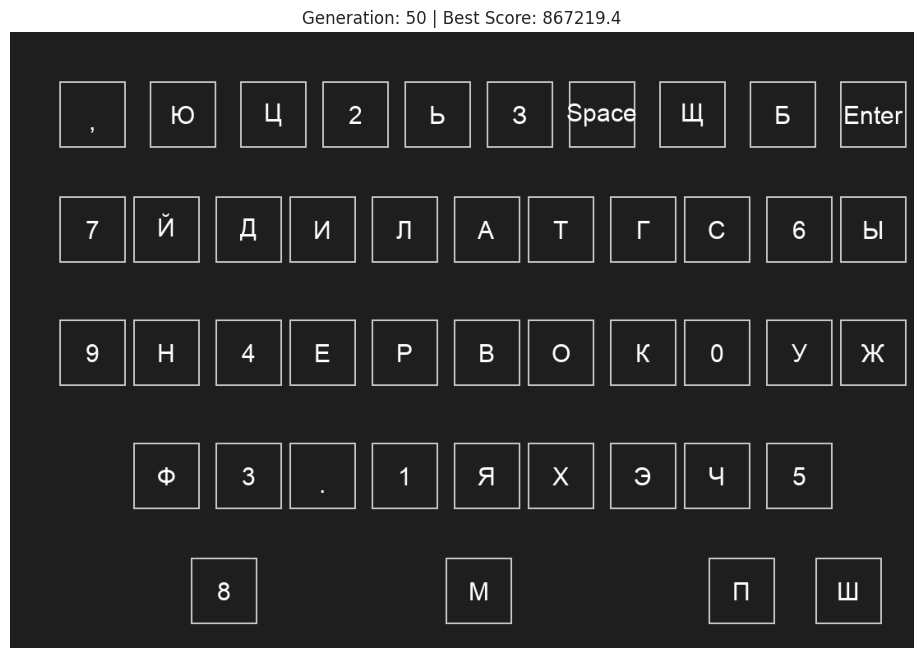

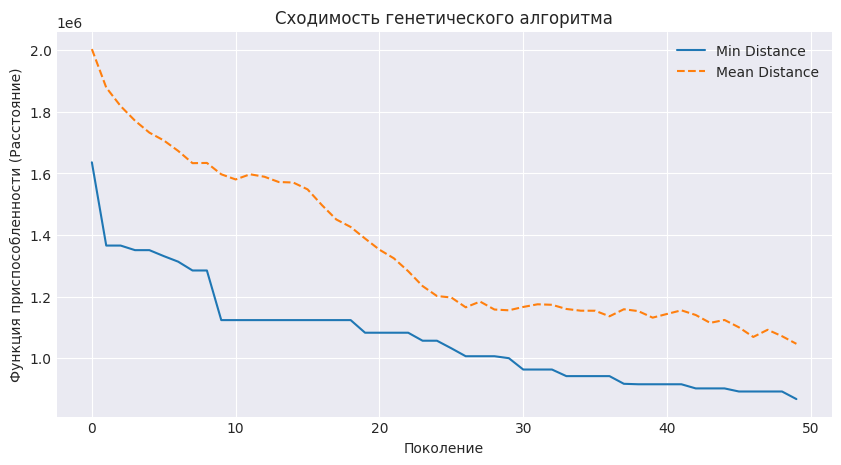

In [87]:
# Параметры ГА
POPULATION_SIZE = 100
NUM_GENERATIONS = 50
ELITE_SIZE = 5

# Инициализация популяции
population = [generate_one() for _ in range(POPULATION_SIZE)]

best_overall_score = float('inf')
best_layout = None
history_best = []
history_avg = []

print("Старт оптимизации...\n")

for gen in range(NUM_GENERATIONS):
    # Оценка
    scores = get_scores(population)
    
    # Статистика
    current_best_score = min(scores)
    current_avg_score = np.mean(scores)
    
    history_best.append(current_best_score)
    history_avg.append(current_avg_score)
    
    # Сохранение глобального рекорда
    if current_best_score < best_overall_score:
        best_overall_score = current_best_score
        best_layout = population[np.argmin(scores)]
    
    # Вывод прогресса каждые 5 поколений
    if gen % 5 == 0 or gen == NUM_GENERATIONS - 1:
        print(f"Поколение {gen}: Лучшее = {current_best_score:.2f}, Среднее = {current_avg_score:.2f}")
        
    # Создание следующего поколения
    population = create_next_generation(population, scores, POPULATION_SIZE, ELITE_SIZE)

print("\nОптимизация завершена!")
print(f"Финальный лучший результат: {best_overall_score:.2f}")

# Визуализация лучшей раскладки
plot_keyboard(best_layout, generation_num=NUM_GENERATIONS, score=best_overall_score)

# График сходимости
plt.figure(figsize=(10, 5))
plt.plot(history_best, label='Min Distance')
plt.plot(history_avg, label='Mean Distance', linestyle='--')
plt.xlabel('Поколение')
plt.ylabel('Функция приспособленности (Расстояние)')
plt.title('Сходимость генетического алгоритма')
plt.legend()
plt.grid(True)
plt.show()